# Bluesky API Tutorial

This notebook uses [Bluesky](https://bsky.social/) data to create and explore directed networks of social interactions.

If you do not have a Bluesky account, please create one. It is free. If you wish, you can do so using an anonymous pseudonym and/or delete your account after you are done with your network science tuorials and exercises.

You can log in with your Bluesky handle (username) and password. Bluesky recommends that to access their data, you use a different password created specifically for the Bluesky Application Programming Interface (API). This is optional, but you will find instructions below to do so.

Afttre login, you will make HyperText Transfer Protocol (HTTP) requests with the Python `requests` package, inspect JavaScript Object Notation (JSON) responses, and use NetworkX to build directed and weighted graphs.

The workflow is the same throughout the notebook:

1. Run an API request.
2. Inspect the JSON response.
3. Decide what should be a node.
4. Decide what interactions create edges and which direction they point.
5. Add edges one at a time, increasing `weight` for repeated interactions between the same two nodes.

Use the table of contents on the top left to navigate to different sections of this tutorial.

# 1 Bluesky API Basics

A web API lets a program ask a service for data. Instead of returning a page for a browser to display, an API usually returns structured data for a program to read.

The basic pattern is the same across many web APIs:

1. Choose an API endpoint Uniform Resource Locator (URL).
2. Send a request with parameters, a JSON body, and/or authorization headers.
3. Check the response status code.
4. Parse the response JSON.
5. Read the fields you need from the JSON object.

In Python, JSON objects become objects, i.e., data structures composed of dictionaries and lists. Useful references: [Requests quickstart](https://requests.readthedocs.io/en/latest/user/quickstart/), [Python `json` docs](https://docs.python.org/3/library/json.html), [The Authenticated Transfer (AT) Protocol used by Bluesky](https://docs.bsky.app/docs/advanced-guides/atproto), and [Bluesky API hosts and authentication](https://docs.bsky.app/docs/advanced-guides/api-directory).


## 1.1 Install Packages

Run this once to install the packages used in this notebook. `requests` handles HTTP requests, NetworkX builds graph objects, and Matplotlib draws the graphs. NetworkX 3.4 or newer is needed for `forceatlas2_layout`.


In [ ]:
# run this to make sure your version of
# networkx is 3.4 or newer.
# This is the case on Colab but double check
# in other environemnts.
!pip show networkx

Name: networkx
Version: 3.6.1
Summary: Python package for creating and manipulating graphs and networks
Home-page: https://networkx.org/
Author: 
Author-email: Aric Hagberg <hagberg@lanl.gov>
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: 
Required-by: hyperopt, mapclassify, momepy, python-louvain, scikit-image, spanner-graph-notebook, spopt, torch


In [ ]:
# run this if the version of networkx shown
# by the previous command is older than 3.4
!pip install -q "networkx>=3.4" requests matplotlib

## 1.2 Imports

Using the `requests` package, each API request shows the URL, parameters, headers, status code, and JSON response.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import json
import requests
from getpass import getpass

## 1.3 API Host and Rate Limits

The Bluesky API had limits on requests it can handle. Requests over a limit usually receive HTTP `429` status code, which means "Too Many Requests".Bluesky's [Rate Limits Guide](https://docs.bsky.app/docs/advanced-guides/rate-limits) explains the limits. API responses typically include `ratelimit-*` headers that help us decide when we have hit a limit and need to wait.

The code below defines a helper function that we will call when sending requests to the API. It looks at response headers and waits when we hit our API limit.


In [ ]:
import time

def safe_request(url, params, auth):
    """
    Input: arguments we use to call requests.get()
    Try the the request.
    Use rate-limit response headers to decide whether to wait.
    If waiting is needed, wait and try again.
    Returns the full response object.
    """

    while(True):
        response = requests.get(url, params=params, headers=auth)
        if response.status_code != 429:
            # Everything seems fine, return the response object
            return response

        # Otherwise, check the request response headers
        retry_after = response.headers.get('retry-after')
        remaining = response.headers.get('ratelimit-remaining')
        reset_at = response.headers.get('ratelimit-reset')

        # retry-after tells us how many seconds to wait before retrying.
        if retry_after:
            wait_seconds = int(retry_after)
        # ratelimit-reset is a Unix timestamp for when the request window resets.
        elif reset_at:
            wait_seconds = max(0, int(reset_at) - int(time.time()))
        else:
            wait_seconds = 60 # default to 60 seconds when not specified in response

        print('Waiting for rate limit:', wait_seconds, 'seconds')
        time.sleep(wait_seconds)

## 1.4 Credentials
This notebook requires Bluesky authentication.

You can use either the password you use to log into the Bluesky app or website (easier but less secure) or create a password specifically to use the API (more secure but optional).

The AT Protocol docs explain why scripts should use an app password: [Software Development Kit (SDK) authentication](https://atproto.com/guides/sdk-auth).

To create an app password, in Bluesky, go to Settings -> Privacy and Security -> App Passwords, [create an app password](https://bsky.app/settings/app-passwords), and then copy the app password to use here. If it is accidentally exposed, you can delete that app password without changing your main account password.

Credential setup is only for API access. Bluesky session authentication uses [`com.atproto.server.createSession`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/com/atproto/server/createSession.json) and can be verified with [`com.atproto.server.getSession`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/com/atproto/server/getSession.json).

You may type your handle and app password in the code below within the `''`s. Or, leave them blank if you want the notebook to ask for them securely when the code runs.

**Do not share this notebook with a real password in the code.**


In [ ]:
BLUESKY_HANDLE = ''
BLUESKY_PASSWORD = ''

if not BLUESKY_HANDLE:
    # input() is for entering text using interactive session
    BLUESKY_HANDLE = input('Bluesky handle, for example yourname.bsky.social: ').strip()

if not BLUESKY_PASSWORD:
    # getpass() hides the text you are entering for privacy
    BLUESKY_PASSWORD = getpass('Bluesky app password: ')

if not BLUESKY_HANDLE or not BLUESKY_PASSWORD:
    raise RuntimeError(
        'A Bluesky handle and app password are required for this tutorial.'
    )



Bluesky handle, for example yourname.bsky.social: osome.iu.edu
Bluesky app password: ··········


## 1.5 Create and Verify a Session

Create a session by sending an HTTP `POST` request. The request body is JSON, and the response body is JSON.

The login response from [`com.atproto.server.createSession`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/com/atproto/server/createSession.json) includes an `accessJwt`. A JSON Web Token (JWT) is a signed string that a server can check. The `accessJwt` proves that this notebook has an active login session. Later requests send it in the HTTP `Authorization` header as `Bearer <accessJwt>` so to avoid the inclusion of username and password in every subsequent requests. The response also includes the account Decentralized Identifier (DID), a stable account identifier used by the AT Protocol.

Since the session response includes secret tokens, the code below does not print the full response JSON.


In [ ]:
# API_BASE is the shared beginning of every Bluesky request URL used below.
# bsky.social is the Bluesky entryway/Personal Data Server (PDS) host.
API_BASE = 'https://bsky.social/xrpc'

In [ ]:
# This endpoint creates an authenticated Bluesky session.
login_url = API_BASE + '/com.atproto.server.createSession'

# The JSON body contains the login identifier and app password.
login_body = {
    'identifier': BLUESKY_HANDLE,
    'password': BLUESKY_PASSWORD,
}

# requests.post sends an HTTP POST request with login_body encoded as JSON.
login_response = requests.post(login_url, json=login_body)
print('Status code:', login_response.status_code)

# raise_for_status() stops the code with an error if the status code is 400 or higher.
# That makes login problems easier to notice immediately.
login_response.raise_for_status()

# .json() parses the JSON response into a Python dictionary.
session = login_response.json()

# accessJwt comes from createSession. Send it as a Bearer token in later requests.
AUTH_HEADERS = {
    'Authorization': 'Bearer ' + session['accessJwt']
}

print('Session created for:', session['handle'])
print('DID:', session['did'])

Status code: 200
Session created for: osome.iu.edu
DID: did:plc:m6sa66thhz7r2dzyxyrk2hzw


Verify the session with [`com.atproto.server.getSession`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/com/atproto/server/getSession.json). This confirms the token works before we request profile and post data.


In [ ]:
get_session_url = API_BASE + '/com.atproto.server.getSession'

# headers=AUTH_HEADERS sends the accessJwt token with this request.
session_response = requests.get(get_session_url, headers=AUTH_HEADERS)
print('Status code:', session_response.status_code)

# If the token is invalid or expired, this line raises an HTTP error.
session_response.raise_for_status()

verified_session = session_response.json()
print('Verified session for:', verified_session['handle'])
print('DID:', verified_session['did'])

Status code: 200
Verified session for: osome.iu.edu
DID: did:plc:m6sa66thhz7r2dzyxyrk2hzw


In the AT Protocol, a Bluesky user is referred to as [`actor`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/app/bsky/actor/defs.json) when they perform an action, or as an [`author`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/app/bsky/feed/defs.json) when they are the creator of a piece of content or a record. The verified session includes the logged-in actor's DID and handle. We can use either the DID or the handle to request the logged-in actor's profile from [`app.bsky.actor.getProfile`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/app/bsky/actor/getProfile.json).


In [ ]:
# actor tells getProfile which account to look up
profile_params = {'actor': verified_session['handle']}

logged_in_profile_response = safe_request(
    API_BASE + '/app.bsky.actor.getProfile',
    profile_params,
    AUTH_HEADERS,
)
print('Status code:', logged_in_profile_response.status_code)

# Stop here if the profile request failed
logged_in_profile_response.raise_for_status()

logged_in_profile = logged_in_profile_response.json()
# json.dumps prints JSON in a readable format,
# in this case the profile JSON returned by the API
print(json.dumps(logged_in_profile, indent=2))

Status code: 200
{
  "did": "did:plc:m6sa66thhz7r2dzyxyrk2hzw",
  "handle": "osome.iu.edu",
  "displayName": "Observatory on Social Media",
  "avatar": "https://cdn.bsky.app/img/avatar/plain/did:plc:m6sa66thhz7r2dzyxyrk2hzw/bafkreicwgt243wbitnas2curk5uqw2x57rsfwhupuv2e66ohq4vkzovffa",
  "associated": {
    "lists": 0,
    "feedgens": 0,
    "starterPacks": 0,
    "labeler": false,
    "activitySubscription": {
      "allowSubscriptions": "followers"
    }
  },
  "viewer": {
    "muted": false,
    "mutedOnlyReposts": false,
    "mutedOnlyQuoteposts": false,
    "blockedBy": false,
    "knownFollowers": {
      "count": 25,
      "followers": [
        {
          "did": "did:plc:t5c4ju4q6k34j6xysrhcoxmt",
          "handle": "yyahn.bsky.social",
          "displayName": "YY Ahn",
          "avatar": "https://cdn.bsky.app/img/avatar/plain/did:plc:t5c4ju4q6k34j6xysrhcoxmt/bafkreihpllb7iz7iiuv7e77udfepxqxzjah2jm36c2xrfn4a2qiaebklb4",
          "associated": {
            "chat": {
       

## 1.6 User Objects

A profile response includes fields such as `did`, `handle`, `displayName`, `followersCount`, `followsCount`, and `postsCount`.

When we build networks, accounts will be the nodes. Let's see where account identifiers live in the JSON.

The default example handle is `osome.iu.edu`.


In [ ]:
# DEFAULT_HANDLE is the example Bluesky account used in this tutorial.
DEFAULT_HANDLE = 'osome.iu.edu'
# DEFAULT_DID = 'did:plc:m6sa66thhz7r2dzyxyrk2hzw'

# actor can be a handle or a Decentralized Identifier (DID).
profile_params = {'actor': DEFAULT_HANDLE}
profile_response = safe_request(
    API_BASE + '/app.bsky.actor.getProfile',
    profile_params,
    AUTH_HEADERS,
)
print('Status code:', profile_response.status_code)

# code stops here if the account cannot be found or the request fails.
profile_response.raise_for_status()

profile = profile_response.json()
print(json.dumps(profile, indent=2))


Status code: 200
{
  "did": "did:plc:m6sa66thhz7r2dzyxyrk2hzw",
  "handle": "osome.iu.edu",
  "displayName": "Observatory on Social Media",
  "avatar": "https://cdn.bsky.app/img/avatar/plain/did:plc:m6sa66thhz7r2dzyxyrk2hzw/bafkreicwgt243wbitnas2curk5uqw2x57rsfwhupuv2e66ohq4vkzovffa",
  "associated": {
    "lists": 0,
    "feedgens": 0,
    "starterPacks": 0,
    "labeler": false,
    "activitySubscription": {
      "allowSubscriptions": "followers"
    }
  },
  "viewer": {
    "muted": false,
    "mutedOnlyReposts": false,
    "mutedOnlyQuoteposts": false,
    "blockedBy": false,
    "knownFollowers": {
      "count": 25,
      "followers": [
        {
          "did": "did:plc:fgshs4zsk5lxvzfesmbo65gs",
          "handle": "ewabu.bsky.social",
          "displayName": "Eric Walsh-Buhi (he/him)",
          "avatar": "https://cdn.bsky.app/img/avatar/plain/did:plc:fgshs4zsk5lxvzfesmbo65gs/bafkreidzmj5s5n7glbrljji2pd3sxbzfiuxwslij245siwysrlgf6o6xna",
          "associated": {
           

## 1.7 Post Views and Post Records

To fetch one recent item from an author's feed, use [`app.bsky.feed.getAuthorFeed`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/app/bsky/feed/getAuthorFeed.json), which sorts the author feed in reverse chronological order, with `limit=1`.

The endpoint returns a `feed` list. Each item in that list is a `feedViewPost`. The `post` field inside a `feedViewPost` is a `postView`, as defined in [`app.bsky.feed.defs`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/app/bsky/feed/defs.json).

A `postView` is the API's view of a post. It is the display-ready wrapper returned by endpoints such as `getAuthorFeed` and `searchPosts`. It includes fields that are useful for reading, displaying, or analyzing the post, such as the Uniform Resource Identifier (URI), Content Identifier (CID), author `profileViewBasic`, reply count, repost count, like count, quote count, embeds, and the underlying `record`.

A post `record` is the actual [`app.bsky.feed.post`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/app/bsky/feed/post.json) record stored by the author's account. It contains the post's own content and structure, such as `text`, `facets`, `reply`, `embed`, and `createdAt`.

The relationship is:

```python
feed[0]                      # this is a feedViewPost
feed[0]['post']              # this is a postView
feed[0]['post']['record']    # this is the post record
```

In practice:

- Use the `postView` when you need author information, post identifiers, interaction counts, or display metadata.
- Use the post `record` when you need the post text, reply reference, quoted record reference, etc.

The code below only fetches one `postView` so the output is easier to inspect.


In [ ]:
# the first post in reverse chronological order is the most recent one
author_feed_url = API_BASE + '/app.bsky.feed.getAuthorFeed'
author_feed_params = {
    'actor': DEFAULT_HANDLE,      # the account whose feed we want to inspect
    'limit': 1,                   # request one feed item only
    'filter': 'posts_no_replies', # skip replies and show an original post
}

recent_post_response = safe_request(
    author_feed_url,
    author_feed_params,
    AUTH_HEADERS,
)
print('Status code:', recent_post_response.status_code)

# Stop here if the feed request failed.
recent_post_response.raise_for_status()

# A feed item contains metadata plus a postView in its 'post' field.
response_object = recent_post_response.json()
recent_feed = response_object['feed']
recent_feed_view_post = recent_feed[0]
recent_post_view = recent_feed_view_post['post']

print('Fetched one feed item for:', DEFAULT_HANDLE)

Status code: 200
Fetched one feed item for: osome.iu.edu


The code below prints the `postView` saved above.


In [ ]:
# Print the postView JSON returned inside the feed response.
print(json.dumps(recent_post_view, indent=2))

{
  "uri": "at://did:plc:m6sa66thhz7r2dzyxyrk2hzw/app.bsky.feed.post/3mg3mtvtous2q",
  "cid": "bafyreid3apqeznkpclpggtplbark7myr65aswx7zow57zenxigurenerom",
  "author": {
    "did": "did:plc:m6sa66thhz7r2dzyxyrk2hzw",
    "handle": "osome.iu.edu",
    "displayName": "Observatory on Social Media",
    "avatar": "https://cdn.bsky.app/img/avatar/plain/did:plc:m6sa66thhz7r2dzyxyrk2hzw/bafkreicwgt243wbitnas2curk5uqw2x57rsfwhupuv2e66ohq4vkzovffa",
    "associated": {
      "activitySubscription": {
        "allowSubscriptions": "followers"
      }
    },
    "viewer": {
      "muted": false,
      "mutedOnlyReposts": false,
      "mutedOnlyQuoteposts": false,
      "blockedBy": false
    },
    "labels": [],
    "createdAt": "2025-01-23T17:23:20.942Z"
  },
  "record": {
    "$type": "app.bsky.feed.post",
    "createdAt": "2026-03-02T16:01:39.072Z",
    "embed": {
      "$type": "app.bsky.embed.images",
      "images": [
        {
          "alt": "",
          "aspectRatio": {
            "h

The post text is stored inside the post record at `postView['record']['text']`.


In [ ]:
# The record is the app.bsky.feed.post record inside the postView.
recent_record = recent_post_view['record']

print(recent_record['text'])

Join us Wednesday at 12pm ET for our final OSoMe Awesome Speaker talk!

🎙️ Alissa Cooper (Knight-Georgetown Institute)
📌 Better Feeds: Algorithms That Put People First

🗓 March 4 | 12pm ET
🔗 Register: iu.zoom.us/meeting/regi...


Bluesky stores rich-text annotations in `record['facets']`.

Facets are structured annotations over parts of the post text, such as hashtags or links. A facet has a byte range indicating the position within the text, plus features describing the facet. Common feature types include mentions, links, and tags. A mention has type `app.bsky.richtext.facet#mention` and stores the mentioned account's DID. A tag has type `app.bsky.richtext.facet#tag` and stores the hashtag text without the `#` symbol.

The Bluesky docs explain facets here: [Links, mentions, and rich text](https://docs.bsky.app/docs/advanced-guides/post-richtext).


In [ ]:
# Facets may be missing, so .get('facets', []) uses an empty list as the default.
recent_facets = recent_record.get('facets', [])

print(json.dumps(recent_facets, indent=2))

[
  {
    "features": [
      {
        "$type": "app.bsky.richtext.facet#link",
        "uri": "https://iu.zoom.us/meeting/register/uvi_xu2kSGifHVQ2bssBaQ"
      }
    ],
    "index": {
      "byteEnd": 241,
      "byteStart": 215
    }
  }
]


The code below reads the facets and prints only mention features. Not every post has mention facets, so an empty list is a normal result.


In [ ]:
recent_mentions = []

for facet in recent_record.get('facets', []):
    # One facet can contain more than one feature.
    for feature in facet.get('features', []):
        # Mention features mark a piece of text that names another account.
        # get() defaults to none, to avoid errors if the type is missing
        if feature.get('$type') == 'app.bsky.richtext.facet#mention':
            recent_mentions.append(feature)

print(recent_mentions)

[]


# 2 Bluesky Search API

The Bluesky search endpoint [`app.bsky.feed.searchPosts`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/app/bsky/feed/searchPosts.json) returns a list of `postView` objects matching a query.

According to the API documentation, `q` is a required search query and cannot be empty. You can search for any keywords, for example `q='pizza margherita'`. Note that if you search for 'science', you will also get posts that have the hashtag #science because hashtags are in the text.  

In the search API, `tag` optionally filters out results without one or more given hashtags. The `tag` value should not include the `#` prefix. For example, using `q='science'` and `tag='IU'` qill return posts about science that include #IU.

If you just wish to search by tags, you can use the same tag also as a query, for example `q='#science'` and `tag='science'`.

In [ ]:
# HASHTAG is the topic we search for. Do not include '#'.
HASHTAG = 'science'

# SEARCH_SORT can be 'top' or 'latest'.
# 'top' often prioritizes posts with many interactions.
SEARCH_SORT = 'top'

search_url = API_BASE + '/app.bsky.feed.searchPosts'
search_params = {
    'q': '#' + HASHTAG, # required search text
    'tag': HASHTAG,     # optional hashtag filter; do not include '#'
    'sort': SEARCH_SORT
}

response = safe_request(
    search_url,
    search_params,
    AUTH_HEADERS
)
print('Status code:', response.status_code)

response.raise_for_status() # code stops here if HTTP error
data = response.json()

print(f"We got {len(data['posts'])} out of {data['hitsTotal']} results")

Status code: 200
We got 25 out of 10000 results


We can see above that `hitsTotal` in the response tells us how many results there are. The default maximim number of results returned by the API is 10,000.

The search endpoint returns results in pages. By default, there are 25 results in each page. If the response has a `cursor`, we can request the next page. This is called pagination. Pagination is common API practice when a dataset is too large for one response.

Each page request counts against the API limits. Below, let us request 1,000 results in larger pages --- 100 posts per page, although in practice there may be fewer, as some results may have been deleted or moderated. We can loop over 10 pages to get these results. This will count 10 queries against our API limit.

In [ ]:
# PAGE_SIZE is how many posts are returned in each page.
# searchPosts allows up to 100.
PAGE_SIZE = 100

search_params = {
    'q': '#' + HASHTAG,
    'tag': HASHTAG,
    'limit': PAGE_SIZE,
    'sort': SEARCH_SORT,
}

results = []           # Each item will be a postView returned by searchPosts

for page in range(10):

    # Send request
    response = safe_request(search_url, search_params, AUTH_HEADERS)

    # Stop execution on HTTP errors such as 401, 429, or 5xx.
    # For example, 502 (BAD GATEWAY) usually means the server is busy
    response.raise_for_status()

    # Get the results
    data = response.json()
    posts_on_page = data['posts']
    print(f'Page {page} status code: {response.status_code}, number of posts: {len(posts_on_page)}')
    results.extend(posts_on_page)

    # After the first page, send the cursor returned by the previous response.
    # This makes sure that the next response will have the next page of results.
    # Stop if we have run out of pages before the end of the loop.
    if 'cursor' in data:
        search_params['cursor'] = data['cursor']
    else:
        break

print('Fetched posts:', len(results))

Page 0 status code: 200, number of posts: 97
Page 1 status code: 200, number of posts: 97
Page 2 status code: 200, number of posts: 98
Page 3 status code: 200, number of posts: 100
Page 4 status code: 200, number of posts: 95
Page 5 status code: 200, number of posts: 97
Page 6 status code: 200, number of posts: 100
Page 7 status code: 200, number of posts: 99
Page 8 status code: 200, number of posts: 99
Page 9 status code: 200, number of posts: 98
Fetched posts: 980


## 2.1 First Search Result

Here is the `postView` from the first search result.

As you inspect the JSON, identify the author fields, post (record) field, and interaction data (counts).

In [ ]:
# first_post is a postView from app.bsky.feed.searchPosts.
first_post = results[0]

print(json.dumps(first_post, indent=2))

{
  "uri": "at://did:plc:5lnenhplvkusidybxeuvuqql/app.bsky.feed.post/3mulba5d7uk2c",
  "cid": "bafyreigs7lwt77q7hk4thb6bbh65lptcebkbfhompctogiye42a4wlsexi",
  "author": {
    "did": "did:plc:5lnenhplvkusidybxeuvuqql",
    "handle": "antifapatriot.bsky.social",
    "displayName": "america.is.not.free",
    "avatar": "https://cdn.bsky.app/img/avatar/plain/did:plc:5lnenhplvkusidybxeuvuqql/bafkreic6j6ainru435zochmm473aatwsca2zhd4rca3muygfmenqxbdnly",
    "associated": {
      "chat": {
        "allowIncoming": "following"
      },
      "activitySubscription": {
        "allowSubscriptions": "followers"
      }
    },
    "viewer": {
      "muted": false,
      "mutedOnlyReposts": false,
      "mutedOnlyQuoteposts": false,
      "blockedBy": false
    },
    "labels": [
      {
        "src": "did:plc:5lnenhplvkusidybxeuvuqql",
        "uri": "at://did:plc:5lnenhplvkusidybxeuvuqql/app.bsky.actor.profile/self",
        "cid": "bafyreic6phzi26rur42wmvr7lqx4gg5fn3fptk32truy3hx54hpwshufwm",
  

Inspect the author profile view for the first search result.

The `author` object below is what appeared inside the search response. In Bluesky terms, it is a [`profileViewBasic`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/app/bsky/actor/defs.json), not the full profile response from `app.bsky.actor.getProfile`. To get the full profile object, call `app.bsky.actor.getProfile` for that author.

In [ ]:
# The nested author object is a profileViewBasic.
first_author = first_post['author']

print(json.dumps(first_author, indent=2))

{
  "did": "did:plc:5lnenhplvkusidybxeuvuqql",
  "handle": "antifapatriot.bsky.social",
  "displayName": "america.is.not.free",
  "avatar": "https://cdn.bsky.app/img/avatar/plain/did:plc:5lnenhplvkusidybxeuvuqql/bafkreic6j6ainru435zochmm473aatwsca2zhd4rca3muygfmenqxbdnly",
  "associated": {
    "chat": {
      "allowIncoming": "following"
    },
    "activitySubscription": {
      "allowSubscriptions": "followers"
    }
  },
  "viewer": {
    "muted": false,
    "mutedOnlyReposts": false,
    "mutedOnlyQuoteposts": false,
    "blockedBy": false
  },
  "labels": [
    {
      "src": "did:plc:5lnenhplvkusidybxeuvuqql",
      "uri": "at://did:plc:5lnenhplvkusidybxeuvuqql/app.bsky.actor.profile/self",
      "cid": "bafyreic6phzi26rur42wmvr7lqx4gg5fn3fptk32truy3hx54hpwshufwm",
      "val": "!no-unauthenticated",
      "cts": "2024-02-19T02:04:09.935Z"
    }
  ],
  "createdAt": "2024-02-19T02:04:08.535Z"
}


Here is a Bluesky web URL for the first search result. Open it to see the post in the Bluesky interface.


In [ ]:
# A Bluesky web post URL uses the author's handle and the post record key (rkey).
# The record key is the last part of the post URI.
post_uri_parts = first_post['uri'].split('/')
post_rkey = post_uri_parts[-1]
first_post_url = (
    'https://bsky.app/profile/'
    + first_post['author']['handle']
    + '/post/'
    + post_rkey
)

print(first_post_url)

https://bsky.app/profile/antifapatriot.bsky.social/post/3mulba5d7uk2c


The most basic text field is inside the post record at `first_post['record']['text']`.


In [ ]:
print(first_post['record']['text'])

🤦🤦‍♀️🥴

#vaccines #healthcare #science #vaccinessavelives #vaccineswork


The `facets` field contains structured annotations such as mentions, links, and tags.


In [ ]:
# Facets are annotations over text, such as mentions, links, and tags.
print(json.dumps(first_post['record']['facets'], indent=2))

[
  {
    "features": [
      {
        "$type": "app.bsky.richtext.facet#tag",
        "tag": "vaccines"
      }
    ],
    "index": {
      "byteEnd": 32,
      "byteStart": 23
    }
  },
  {
    "features": [
      {
        "$type": "app.bsky.richtext.facet#tag",
        "tag": "healthcare"
      }
    ],
    "index": {
      "byteEnd": 44,
      "byteStart": 33
    }
  },
  {
    "features": [
      {
        "$type": "app.bsky.richtext.facet#tag",
        "tag": "science"
      }
    ],
    "index": {
      "byteEnd": 53,
      "byteStart": 45
    }
  },
  {
    "features": [
      {
        "$type": "app.bsky.richtext.facet#tag",
        "tag": "vaccinessavelives"
      }
    ],
    "index": {
      "byteEnd": 72,
      "byteStart": 54
    }
  },
  {
    "features": [
      {
        "$type": "app.bsky.richtext.facet#tag",
        "tag": "vaccineswork"
      }
    ],
    "index": {
      "byteEnd": 86,
      "byteStart": 73
    }
  }
]


The code below finds a search result with at least one mention, then prints the mention features.


In [ ]:
# Find the first post in the search results that contains a mention facet.
mention_post = False

for post in results:
    facets = post['record']['facets']

    # Check each facet for a mention feature.
    for facet in facets:
        feature = facet.get('features', [{}])[0] # make sure this does not break if no features
        if feature.get('$type') == 'app.bsky.richtext.facet#mention':
            mention_post = True
            print(f'User with handle {post['author']['handle']} mentioned user with DID {feature['did']}')

    # Stop searching posts once a mention is found.
    if mention_post:
        break

if not mention_post:
    print('No mention facets were found in this search sample.')

User with handle jordanhallwx.bsky.social mentioned user with DID did:plc:d3rehtj2m7lm3m6nxs33dkhh


# 3 Social Network Graphs

In this section, we use NetworkX to create social networks from Bluesky data. Users are nodes, and interactions among users are directed edges.

Each network follows the same workflow:

1. Define what interactions create edges.
3. Decide the edge direction. As a convention, we draw edges in the direction of information flow.
4. Count repeated interactions as edge weights.
5. Analyze the resulting directed, weighted network.

NetworkX references:

- [`DiGraph`](https://networkx.org/documentation/stable/reference/classes/digraph.html)
- [`DiGraph.add_node`](https://networkx.org/documentation/stable/reference/classes/generated/networkx.DiGraph.add_node.html)
- [`DiGraph.add_edge`](https://networkx.org/documentation/stable/reference/classes/generated/networkx.DiGraph.add_edge.html)
- [NetworkX Drawing](https://networkx.org/documentation/stable/reference/drawing.html)
- [`nx.draw`](https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw.html)
- [`nx.forceatlas2_layout`](https://networkx.org/documentation/stable/reference/generated/networkx.drawing.layout.forceatlas2_layout.html)

ForceAtlas2 is a force-directed layout algorithm designed for Gephi. We use NetworkX's implementation here.


## 3.1 Repost Network

Build a directed network based on reposts.

A repost is evidence that a message spread from one account (and its audience) to another account (and its audience). A repost network helps us understand how information spreads through the network.

The search results only return posts with content (original posts, replies, and quotes). However, if a source post has been reposted, its `postView` has a non-zero repost count. We can use this information to look for repost edges. To find the accounts that reposted a source post, call [`app.bsky.feed.getRepostedBy`](https://raw.githubusercontent.com/bluesky-social/atproto/main/lexicons/app/bsky/feed/getRepostedBy.json).

As a convention, we draw edges in the direction of information flow: from the original author to the user who reposted.

In [ ]:
# MAX_REPOST_SOURCE_POSTS controls how many original posts
# we inspect while looking for reposters.
# This helps control the number of API requests we will make
MAX_REPOST_SOURCE_POSTS = 25

# find the posts that have been reposted the most
# among our previous search results
top_reposted = sorted(
    results,
    key=lambda postView: postView['repostCount'],
    reverse=True
)[:MAX_REPOST_SOURCE_POSTS]

# Make sure we only consider posts that have been reposted
top_reposted = [postView for postView in top_reposted if postView['repostCount'] > 0]

print('Posts with reposts selected:', len(top_reposted))

Posts with reposts selected: 25


In [ ]:
# API endpoint to get reposters
reposted_by_url = API_BASE + '/app.bsky.feed.getRepostedBy'

# A directed graph stores directed edges.
# Here each edge means original author -> reposter.
D = nx.DiGraph()

for post in top_reposted:
    original_author = post['author']['handle']
    D.add_node(original_author)

    # The getRepostedBy endpoint takes the URI of a post to get its reposts
    # By default it returns 50 reposts, the maximum limit is 100
    repost_params = {
        'uri': post['uri'],   # which post we want reposters for
        'limit': 100          # maximum reposters to return for this post
    }

    response = safe_request(reposted_by_url, repost_params, AUTH_HEADERS)
    response.raise_for_status()
    repost_page = response.json()
    reposters = repost_page['repostedBy']
    print(f'status code: {response.status_code}. {len(reposters)} reposted user {original_author}.')

    # loop over the users who reposted this post
    for reposter in reposters:
        reposter_handle = reposter['handle']

        # If the edge already exists, increase its weight.
        if D.has_edge(original_author, reposter_handle):
            D.edges[original_author, reposter_handle]['weight'] += 1
        else:
            # If the edge is new, create it with weight 1.
            D.add_edge(original_author, reposter_handle, weight=1)

print('Nodes:', D.number_of_nodes())
print('Edges:', D.number_of_edges())

status code: 200. 98 reposted user antifapatriot.bsky.social.
status code: 200. 98 reposted user antifapatriot.bsky.social.
status code: 200. 97 reposted user drscotthadland.bsky.social.
status code: 200. 99 reposted user antifapatriot.bsky.social.
status code: 200. 100 reposted user mizati.bsky.social.
status code: 200. 96 reposted user antifapatriot.bsky.social.
status code: 200. 99 reposted user antifapatriot.bsky.social.
status code: 200. 97 reposted user pestilence4all.bsky.social.
status code: 200. 97 reposted user petergleick.bsky.social.
status code: 200. 100 reposted user tobiquemike.bsky.social.
status code: 200. 100 reposted user corrina.sheshed.rocks.
status code: 200. 98 reposted user bergamax.bsky.social.
status code: 200. 97 reposted user jmzmuda.bsky.social.
status code: 200. 98 reposted user pestilence4all.bsky.social.
status code: 200. 98 reposted user pestilence4all.bsky.social.
status code: 200. 96 reposted user sheril.bsky.social.
status code: 200. 100 reposted use

### Repost Network Analysis

Since edges point from the original author to the reposter, out-degree counts how many different users reposted a source author.


In [ ]:
most_reposted_user = max(D.nodes, key=lambda node: D.out_degree(node))
print(most_reposted_user, D.out_degree(most_reposted_user))

antifapatriot.bsky.social 554


Out-strength (weighted out-degree) counts repeated repost relationships. Multiple posts by the same author can be resposted by the same user.  


In [ ]:
most_reposted_user_weighted = max(
    D.nodes,
    key=lambda node: D.out_degree(node, weight='weight'),
)
print(
    most_reposted_user_weighted,
    D.out_degree(most_reposted_user_weighted, weight='weight'),
)

antifapatriot.bsky.social 690


Weakly connected components show which groups of accounts are connected by some path if we ignore edge direction. Here, each component can be interpreted as a separate cluster of interaction around the searched topic.

In [ ]:
repost_components = list(nx.weakly_connected_components(D))
largest_repost_component = max(repost_components, key=len)

print('Weakly connected components:', len(repost_components))
print('Largest component size:', len(largest_repost_component))

Weakly connected components: 2
Largest component size: 1759


### Draw the Repost Network

This drawing uses ForceAtlas2 to compute node positions, then uses [`nx.draw`](https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw.html) to draw the graph.

It is slower than the default, but produces nicer results for large networks. Be patient.


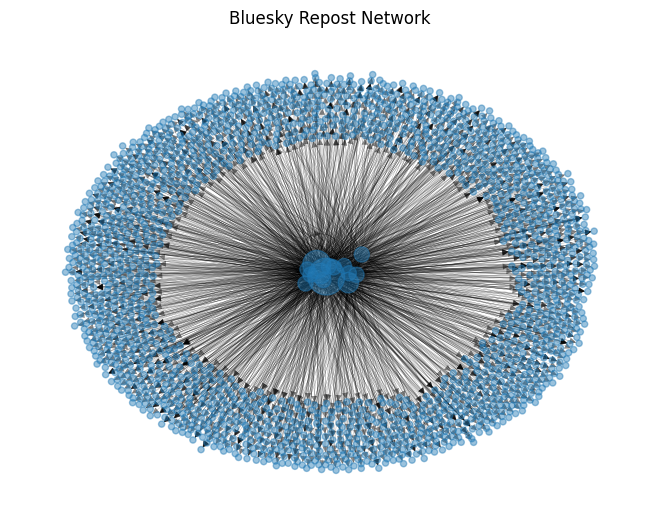

In [ ]:
# node_size controls the area of each node. Larger out-strength means a larger node.
node_sizes = [20 + D.out_degree(node, weight='weight') for node in D.nodes]

# width controls edge thickness. Here repeated reposts draw thicker edges.
edge_widths = [D.edges[edge]['weight'] * 0.2 for edge in D.edges]

# ForceAtlas2 can take a while! Be patient.
# pos stores the x/y position for each node.
pos = nx.forceatlas2_layout(D)

nx.draw(
    D,
    pos=pos,
    node_size=node_sizes,
    width=edge_widths,
    alpha=0.45,       # alpha controls transparency
    arrows=True,      # arrows show edge direction
    with_labels=False # labels are hidden because this graph can be crowded
)

plt.title('Bluesky Repost Network')
plt.show()

## 3.2 Try This: Mention Network

Now try building a **mention network** from the posts you collected.

Mentions are stored in rich-text facets. Use these facets to identify which accounts are mentioned in each post. The facet feature contains the mentioned account's DID, which you can use and a node ID in the mention network.

Construct a directed graph where an edge from **A → B** means that **A mentioned B**. The idea is that B sees the post that mentions them, so information is flowing from A to B. If A mentions B multiple times in the sample, increase the weight of that edge accordingly.

As you build the network, consider what the resulting graph tells you about which accounts are frequently mentioned and which users do most of the mentioning.

### Hints

- Create a directed graph with `nx.DiGraph()`.
- Loop through the posts in `results`.
- Look for `app.bsky.richtext.facet#mention` features in each post's facets.
- Use the edge `weight` to count repeated mentions.
- When you're finished, report the number of nodes and edges in your network.


In [ ]:
# Build the mention network here

Now imagine you want to build the mention network using account handles as node IDs rather than DIDs. The facet byte range can be used to recover the visible `@handle` from the post text.

Repeat your mention network construction, but modify your code to extract handles and use those to identify accounts.

Facet positions refer to **UTF-8 byte ranges**, not Python string positions. As a hint, below is code that extracts the handle from a search result.



In [ ]:
# Here is a post that includes a couple of mentions:
# https://bsky.app/profile/fil.bsky.social/post/3mt3j4yvwqk27
# We are going to use a very specific query that returns
# exactly that post (this is called a "silver bullet query")

search_params = {
    'q': 'Great report by @eileenguo.bsky.social @giselilla.bsky.social \
    @cargocultscientist.bsky.social. The CIC conspiracy roots go even \
    further back. In 2014, our research on disinformation spread on social media \
    was falsely accused of being a secret censorship operation\
    www.science.org/content/arti...'
}
response = safe_request(
    search_url,
    search_params,
    AUTH_HEADERS
)
print('Status code:', response.status_code)
response.raise_for_status() # code stops here if HTTP error
post = response.json()['posts'][0]

mentioner_handle = post['author']['handle']
print('\nMentioner account handle:', mentioner_handle)

mentioned_accounts = []
record = post['record']
for facet in record.get('facets', []):
    for feature in facet.get('features', []):
        # Mention features mark a piece of text that names another account.
        if feature.get('$type') == 'app.bsky.richtext.facet#mention':
            range_start = facet['index']['byteStart']
            range_end = facet['index']['byteEnd']
            # Bluesky facet ranges are UTF-8 byte offsets.
            mentioned_handle = (
                record['text'].encode('utf-8')[range_start:range_end]
                .decode('utf-8')
                .removeprefix('@')
            )
            mentioned_accounts.append(mentioned_handle)

for mentioned_handle in mentioned_accounts:
    print(f'{mentioner_handle} mentioned {mentioned_handle}')

Status code: 200

Mentioner account handle: fil.bsky.social
fil.bsky.social mentioned eileenguo.bsky.social
fil.bsky.social mentioned giselilla.bsky.social
fil.bsky.social mentioned cargocultscientist.bsky.social


In [ ]:
# Build the mention network using account handles here

### Mention Network Analysis

In [ ]:
# Your code here

### Draw the Mention Network

In [ ]:
# Your code here

## 3.3 Try This: Reply Network

Now try building a **reply network** from the posts you collected.

A reply stores a reference to its parent post (the post to which it replies) in `record['reply']['parent']['uri']`. To identify the account being replied to, you will need to retrieve the parent post and inspect its author.

Choose a direction for your edges and use it consistently. One useful convention is **parent author → reply author**, which follows the conversation from the parent post to the reply to indicate that the replier has seen the parent post. If the same pair interacts more than once, increase the edge weight.

### Hints

- Create a directed graph with `nx.DiGraph()`.
- Loop through `results` and keep only posts that contain a `reply`.
- Extract the parent post URI from `reply['parent']['uri']`.
- Look at the URI and notice how you can extract the parent author's DID from it.
- Then use the `app.bsky.actor.getProfile` endpoint as we have seen earlier in this tutorial. Look up the documentation to see how to pass the user's DID instead of their handle, then you can extract the handle.
- If you are calling this endpoint more than a few times, use the `safe_request` helper function to make sure you do not run into API limit errors.
- Some parent posts may be deleted, blocked, or otherwise unavailable, so check that a result was returned before using it.
- Store repeated interactions using an edge `weight`.
- When finished, report the number of nodes and edges in the reply network. Then consider which degree/strength measures best answer your questions about reply activity.

For reference, Bluesky documents [replies and quote posts](https://docs.bsky.app/docs/advanced-guides/posts#replies-quote-posts-and-embeds).


In [ ]:
# Build the reply network here

### Reply Network Analysis

In [ ]:
# Your code here

### Draw the Reply Network

In [ ]:
# Your code here

## 3.4 Try This: Quote Network

Now try building a **quote network** from the posts you collected.

A quote post is a post record that embeds another post record. Bluesky's post guide describes [replies, quote posts, and embeds](https://docs.bsky.app/docs/advanced-guides/posts#replies-quote-posts-and-embeds).

In this network, be sure to set the edge direction appropriately (we normally use the convention of following information flow). If A quotes B more than once in the sample, increase the edge weight.

### Hints

- Create a directed graph with `nx.DiGraph()`.
- Loop through `results` and inspect each post's `embed`.
- Determine whether the embed contains a quoted record before trying to read it.
- Use the edge `weight` to count repeated quotes between the same pair of accounts.
- When finished, report the number of nodes and edges.

### Quote Post Example

The code below illustrates how to extract the handles of two users, one who quotes and one who is quoted.

In [ ]:
# Refer back to the silver bullet query from the mention network example.
# This code should work unless you have reused the variable `post`;
# if you have, copy that code here and run it again...
# ...
quoter_handle = post['author']['handle']

# A quote post has an embed that contains a quoted record.
# Your data may not have these; be sure to handle missing fields!
quoted_handle = post['embed']['record']['author']['handle']

print(f'{quoter_handle} quoted {quoted_handle}')

fil.bsky.social quoted eileenguo.bsky.social


In [ ]:
# Build the quote network here

### Quote Network Analysis

In [ ]:
# Your code here

### Draw the Quote Network

In [ ]:
# Your code here